# Notebook 3 — Behavioural-composite approach: split animals on *memory*, then compare rhythms

### Why this is the reverse of Notebook 2
Notebook 2 classified animals by a composite *circadian* dysfunction score and asked
whether the two groups differed behaviourally. Here we flip the direction: classify
animals by *memory* performance and ask whether the two groups differ in circadian
rhythm quality.

Statistically, the association between the two composites is one quantity — so these
two notebooks are not independent pieces of evidence, they are two framings of the
same relationship. The value of this notebook is: (a) it is the framing a PI who
thinks of memory as the primary outcome will find natural; (b) it exposes whether the
two memory domains (Barnes vs NOR) agree or disagree about who is cognitively
resilient, which is itself informative.

### Design choices (justified above in the conversation)
- **Old animals only (n = 40)** — matches Notebook 2.
- **Barnes and NOR kept separate** — they index different cognitive circuitry (hippocampal
  vs perirhinal), have different missingness, and we already know rhythm amplitude
  correlates with them in *opposite* directions in Old Males. Combining them would
  cancel that out.
- **Barnes composite** = z-mean of the two *target-fidelity* measures that empirically
  co-vary at trial 6 in this cohort: target-zone entries and target-quadrant % time
  (Pearson r = +0.57). Candidate inputs that did *not* co-vary coherently with these
  — `Hole_errors`, `Goal_Box_latency_new`, and `learning_slope` — were excluded from
  the composite (see the diagnostic cell in Step 1 for the correlation matrix).
- **Barnes learning slope** is kept as a *separate* behavioural axis. Slope measures
  rate of improvement across trials, which is empirically and conceptually distinct
  from final trial-6 fidelity (r ≈ −0.2 with both composite inputs).
- **NOR score** = `DI_duration` directly. It's already a ratio of novel vs familiar
  exploration; compositing it further would be double-counting.
- **Median split** on each, and a **continuous-correlation** robustness section to
  avoid dichotomisation loss of power.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_context("notebook")
sns.set_style("whitegrid")

REPO = Path.cwd().parent.parent  # notebook lives at poster_analysis/vulnerability_resilience_analysis/

# Circadian_raw has ID, PRE_POST, metrics, Age_new, Sex_new, Light_new
circ = pd.read_csv(REPO / "Circadian_raw.csv").rename(columns={"PRE.POST": "PRE_POST"})
metrics_base = ["IS", "IV", "RA", "Amplitude"]
wide = circ.pivot_table(
    index="ID", columns="PRE_POST", values=metrics_base
)
wide.columns = [f"{m}_{p.lower()}" for m, p in wide.columns]
wide = wide.reset_index()

grp = (
    circ[["ID", "Sex_new", "Age_new", "Light_new"]]
    .drop_duplicates(subset="ID")
    .reset_index(drop=True)
)
wide = wide.merge(grp, on="ID", how="left")

# Barnes — trial-6 endpoints + learning slope
barnes = pd.read_csv(REPO / "Barnes_clean.csv")
t6 = barnes[barnes["Trial"] == 6][["ID", "EntryZone_freq_new", "Q4"]].rename(
    columns={"EntryZone_freq_new": "barnes_entries_t6", "Q4": "barnes_Q4_pct"}
    # Q4 = target (goal) quadrant; Q1 = opposite quadrant. Per sex_age_effects.py.
    # Higher Q4 % = more time in the correct quadrant = better spatial memory.
)
slopes = pd.read_csv(REPO / "learning_slopes_per_mouse.csv")[["ID", "learning_slope"]]

# NOR
nor = pd.read_csv(REPO / "UCBAge_Novel_clean.csv").rename(columns={"Animal_ID": "ID"})
nor["DI_duration"] = (nor["N_obj_nose_duration_s"] - nor["F_obj_nose_duration_s"]) / (
    nor["N_obj_nose_duration_s"] + nor["F_obj_nose_duration_s"]
)
nor = nor[["ID", "DI_duration"]]

master = wide.merge(t6, on="ID", how="left").merge(slopes, on="ID", how="left").merge(
    nor, on="ID", how="left"
)

# FILTER TO OLD ANIMALS
old = master[master["Age_new"] == "Old"].copy().reset_index(drop=True)
print(f"Old animals: n = {len(old)}")
old.head()


Old animals: n = 40


,ID,Amplitude_post,Amplitude_pre,IS_post,IS_pre,IV_post,IV_pre,RA_post,RA_pre,Sex_new,Age_new,Light_new,barnes_entries_t6,barnes_Q4_pct,learning_slope,DI_duration
0,1,2.861,2.777,0.292,0.405,1.212,1.136,0.251,0.432,Male,Old,CTR,0.0,33.9755,0.011797,0.175988
1,4,1.860,2.976,0.259,0.520,0.899,1.188,0.279,0.370,Male,Old,CTR,0.0,44.2134,-0.065625,0.276134
2,6,2.668,2.086,0.492,0.549,1.343,1.617,0.469,0.801,Male,Old,ISF,1.0,48.3363,-0.020119,0.434378
3,7,0.627,0.787,0.082,0.078,1.762,1.163,0.023,0.052,Male,Old,CTR,5.0,42.0315,0.008642,0.421712
4,8,2.175,2.372,0.329,0.533,1.072,1.539,0.359,0.413,Male,Old,CTR,0.0,58.4939,0.054414,0.751609


## Step 1 — Justify the composite structure empirically, then build the scores

Before averaging anything, we check which Barnes measures actually co-vary in this
cohort. The standard trial-6 Barnes endpoints are:

- `EntryZone_freq_new` — target zone entries (higher = better)
- `Q4`                  — target quadrant % time (higher = better)
- `Hole_errors`         — wrong-hole pokes (lower = better, so use negated)
- `Goal_Box_latency`    — time to escape (lower = better, so use negated)
- `learning_slope`      — per-mouse slope across trials 1–5 (higher = better)

If all five indexed one latent "spatial memory" factor, after sign flipping they should
all correlate positively. Let's see if they do.


Old animals with all 5 non-missing: n = 38

Pairwise Pearson correlations (all sign-flipped so higher = better):
                entries  Q4 (target)  learning slope  −Hole_errors  −Goal_latency
entries           1.000        0.566          -0.181        -0.517          0.016
Q4 (target)       0.566        1.000          -0.207        -0.003         -0.037
learning slope   -0.181       -0.207           1.000         0.251         -0.340
−Hole_errors     -0.517       -0.003           0.251         1.000         -0.293
−Goal_latency     0.016       -0.037          -0.340        -0.293          1.000


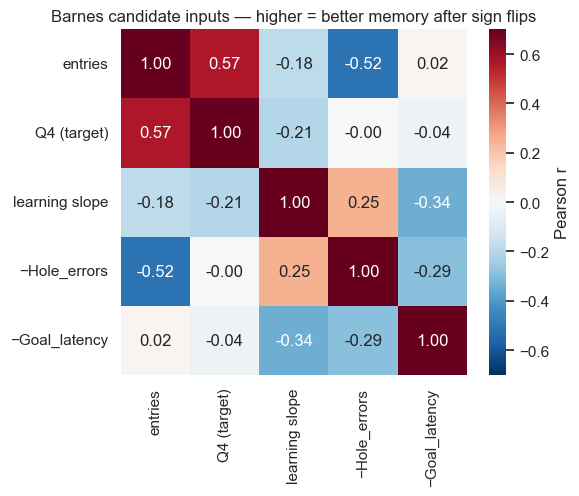

In [2]:
# Correlation matrix of the 5 candidate Barnes inputs, all sign-flipped so higher = better memory
b_raw = pd.read_csv(REPO / "Barnes_clean.csv")
t6_raw = b_raw[b_raw["Trial"] == 6][["ID", "EntryZone_freq_new", "Q4",
                                     "Hole_errors", "Goal_Box_latency_new"]]
diag = old[["ID"]].merge(t6_raw, on="ID", how="left")
diag = diag.merge(old[["ID", "learning_slope"]], on="ID", how="left")
diag["Hole_errors_neg"] = -diag["Hole_errors"]
diag["Goal_Box_latency_neg"] = -diag["Goal_Box_latency_new"]

DIAG_COLS = ["EntryZone_freq_new", "Q4", "learning_slope",
             "Hole_errors_neg", "Goal_Box_latency_neg"]
pretty = {"EntryZone_freq_new": "entries", "Q4": "Q4 (target)",
          "learning_slope": "learning slope",
          "Hole_errors_neg": "−Hole_errors", "Goal_Box_latency_neg": "−Goal_latency"}
sub = diag.dropna(subset=DIAG_COLS)
print(f"Old animals with all 5 non-missing: n = {len(sub)}")
corr = sub[DIAG_COLS].corr().rename(columns=pretty, index=pretty)
print("\nPairwise Pearson correlations (all sign-flipped so higher = better):")
print(corr.round(3).to_string())

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-0.7, vmax=0.7, square=True, ax=ax,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Barnes candidate inputs — higher = better memory after sign flips")
plt.tight_layout(); plt.show()


**Reading the matrix.**

- `entries` and `Q4` co-vary strongly (r ≈ +0.57) — both measure target-zone fidelity.
- `Hole_errors` (after sign flip) correlates *negatively* with `entries` (r ≈ −0.52).
  High-activity animals make more entries *and* more wrong pokes — a locomotor confound.
  Including it would subtract from the target-fidelity signal.
- `Goal_Box_latency` is near-zero with most inputs — it measures escape efficiency,
  a conceptually different construct.
- `learning_slope` correlates weakly *negatively* (r ≈ −0.2) with the two fidelity
  measures. Slope is rate-of-improvement, empirically distinct from final performance.

**Decision.** The Barnes composite will use only `entries` + `Q4` — the two measures
that actually index the same latent construct in this cohort. `learning_slope` will
be kept as a separate behavioural axis and analysed in parallel. `Hole_errors` and
`Goal_Box_latency` are dropped.


In [3]:
# Barnes composite: target-zone fidelity only (the two measures that co-vary at r≈+0.57)
BARNES_COLS = ["barnes_entries_t6", "barnes_Q4_pct"]
for c in BARNES_COLS:
    assert c in old.columns, f"{c} missing in master table"

barnes_z = old[BARNES_COLS].apply(
    lambda col: (col - col.mean()) / col.std(ddof=1)
)
old["barnes_score"] = barnes_z.mean(axis=1)

# Keep learning_slope as a separate standalone axis
old["slope_score"] = old["learning_slope"]

# NOR score = DI_duration directly
old["nor_score"] = old["DI_duration"]

# Sanity counts
print(f"Barnes fidelity composite n non-missing: {old['barnes_score'].notna().sum()} / {len(old)}")
print(f"Learning slope            n non-missing: {old['slope_score'].notna().sum()} / {len(old)}")
print(f"NOR score                 n non-missing: {old['nor_score'].notna().sum()} / {len(old)}")
print()
print("Barnes composite z-loadings (each input's r with the fidelity composite):")
for c in BARNES_COLS:
    r = old[[c, "barnes_score"]].corr().iloc[0, 1]
    print(f"  {c:25s}  r with composite = {r:+.3f}")
print()
print("Independence check — Barnes fidelity composite vs learning slope:")
d = old.dropna(subset=["barnes_score", "slope_score"])
r = d[["barnes_score", "slope_score"]].corr().iloc[0, 1]
print(f"  r = {r:+.3f}  (if near zero, they index genuinely different constructs)")


Barnes fidelity composite n non-missing: 38 / 40
Learning slope            n non-missing: 38 / 40
NOR score                 n non-missing: 36 / 40

Barnes composite z-loadings (each input's r with the fidelity composite):
  barnes_entries_t6          r with composite = +0.885
  barnes_Q4_pct              r with composite = +0.885

Independence check — Barnes fidelity composite vs learning slope:
  r = -0.219  (if near zero, they index genuinely different constructs)


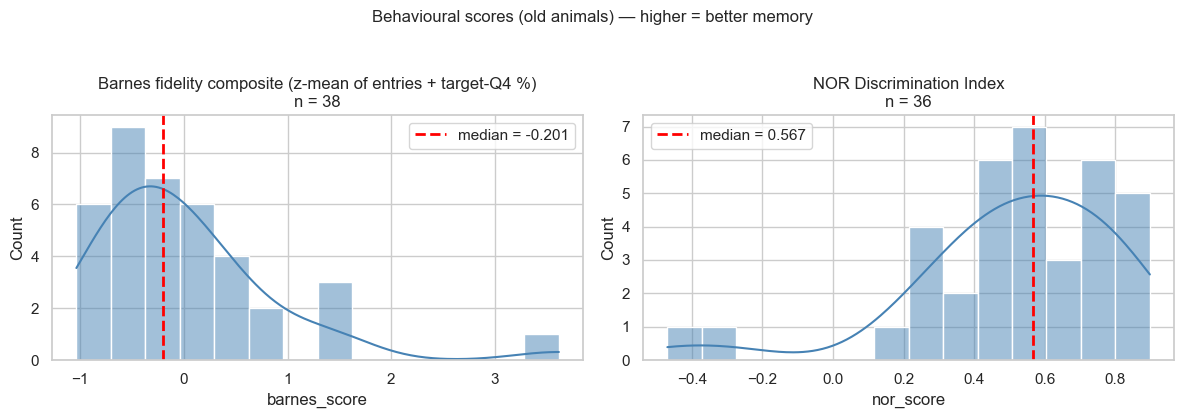

In [4]:
# Visualise the distributions of both scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(
    axes,
    ["barnes_score", "nor_score"],
    ["Barnes fidelity composite (z-mean of entries + target-Q4 %)", "NOR Discrimination Index"]
):
    vals = old[col].dropna()
    sns.histplot(vals, bins=14, kde=True, ax=ax, color="steelblue")
    med = vals.median()
    ax.axvline(med, color="red", ls="--", lw=2, label=f"median = {med:.3f}")
    ax.set_title(f"{label}\nn = {len(vals)}")
    ax.legend()
plt.suptitle("Behavioural scores (old animals) — higher = better memory",
             y=1.04, fontsize=12)
plt.tight_layout(); plt.show()


The Barnes composite correlations with its inputs show whether averaging them is
defensible: all three should have positive correlations with the composite. If one
loads near zero or negative, re-think the composite before splitting.


## Step 2 — Median-split each score into resilient / impaired

In [5]:
old["barnes_group"] = np.where(old["barnes_score"] > old["barnes_score"].median(),
                               "resilient", "impaired")
old.loc[old["barnes_score"].isna(), "barnes_group"] = np.nan

old["nor_group"] = np.where(old["nor_score"] > old["nor_score"].median(),
                            "resilient", "impaired")
old.loc[old["nor_score"].isna(), "nor_group"] = np.nan

print("Barnes classification counts:")
print(old["barnes_group"].value_counts(dropna=False).to_string())
print("\nNOR classification counts:")
print(old["nor_group"].value_counts(dropna=False).to_string())


Barnes classification counts:
barnes_group
impaired     19
resilient    19
NaN           2

NOR classification counts:
nor_group
impaired     18
resilient    18
NaN           4


## Step 3 — Do Barnes and NOR agree about *who* is cognitively resilient?

Cross-tab (n = 36 animals with both scores):
NOR        impaired  resilient
Barnes                        
impaired          7         10
resilient        11          8

Agreement (% same label): 41.7%
Cohen's kappa:            -0.167


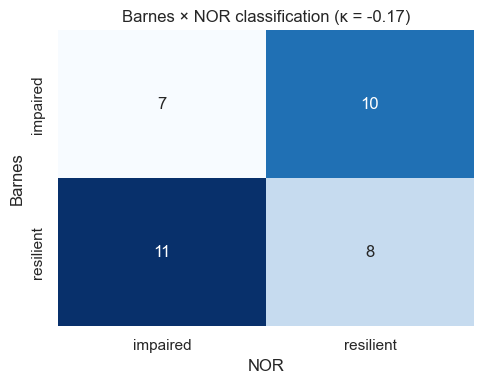

In [6]:
# Cross-tabulate the two classifications and compute Cohen's kappa
# (hand-rolled — no sklearn dependency).
mask = old[["barnes_group", "nor_group"]].dropna()
a = mask["barnes_group"].values
b = mask["nor_group"].values
po = (a == b).mean()                                        # observed agreement
pa = pd.Series(a).value_counts(normalize=True)
pb = pd.Series(b).value_counts(normalize=True)
pe = sum(pa.get(k, 0) * pb.get(k, 0) for k in set(a) | set(b))  # chance agreement
kappa = (po - pe) / (1 - pe) if pe < 1 else np.nan

tab = pd.crosstab(mask["barnes_group"], mask["nor_group"],
                  rownames=["Barnes"], colnames=["NOR"])
print(f"Cross-tab (n = {len(mask)} animals with both scores):")
print(tab.to_string())
print(f"\nAgreement (% same label): {(mask['barnes_group'] == mask['nor_group']).mean()*100:.1f}%")
print(f"Cohen's kappa:            {kappa:+.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(tab, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title(f"Barnes × NOR classification (κ = {kappa:+.2f})")
plt.tight_layout(); plt.show()


**Read this table carefully.** If κ is near 0, the two memory domains are classifying
animals almost independently — that is itself the finding. It would mean **there is no
single "good memory" axis in old animals**; spatial performance and recognition
performance are separately variable. It would also be a strong argument against
collapsing them into one composite (and against any single-metric claim that an
animal is "cognitively vulnerable" full-stop).


## Step 4 — Do the circadian metrics differ between Barnes-impaired vs Barnes-resilient?

In [7]:
CIRC_METRICS_POST = ["IS_post", "IV_post", "RA_post", "Amplitude_post"]

def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

def compare(group_col, metrics):
    rows = []
    for m in metrics:
        imp = old.loc[old[group_col] == "impaired", m].dropna().values
        res = old.loc[old[group_col] == "resilient", m].dropna().values
        if len(imp) < 2 or len(res) < 2: continue
        U, p = stats.mannwhitneyu(imp, res, alternative="two-sided")
        d = cohens_d(imp, res)
        rows.append({"metric": m, "n_imp": len(imp), "n_res": len(res),
                     "mean_imp": imp.mean(), "mean_res": res.mean(),
                     "Cohen_d": d, "MWU_p": p})
    return pd.DataFrame(rows).round(3)

print("=== Circadian metrics by BARNES classification ===")
barnes_cmp = compare("barnes_group", CIRC_METRICS_POST)
print(barnes_cmp.to_string(index=False))
print("\n=== Circadian metrics by NOR classification ===")
nor_cmp = compare("nor_group", CIRC_METRICS_POST)
print(nor_cmp.to_string(index=False))


=== Circadian metrics by BARNES classification ===
        metric  n_imp  n_res  mean_imp  mean_res  Cohen_d  MWU_p
       IS_post     19     19     0.452     0.430    0.128  0.661
       IV_post     19     19     1.240     1.209    0.110  1.000
       RA_post     19     19     0.451     0.435    0.067  0.530
Amplitude_post     19     19     2.604     2.813   -0.148  0.953

=== Circadian metrics by NOR classification ===
        metric  n_imp  n_res  mean_imp  mean_res  Cohen_d  MWU_p
       IS_post     18     18     0.440     0.430    0.059  0.975
       IV_post     18     18     1.250     1.242    0.033  0.887
       RA_post     18     18     0.435     0.417    0.076  0.962
Amplitude_post     18     18     3.068     2.353    0.510  0.159


/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75685/3411363901.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=group_col, y=m,
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75685/3411363901.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=group_col, y=m,
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75685/3411363901.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=group_col, y=m,
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75685/3411363901.py:

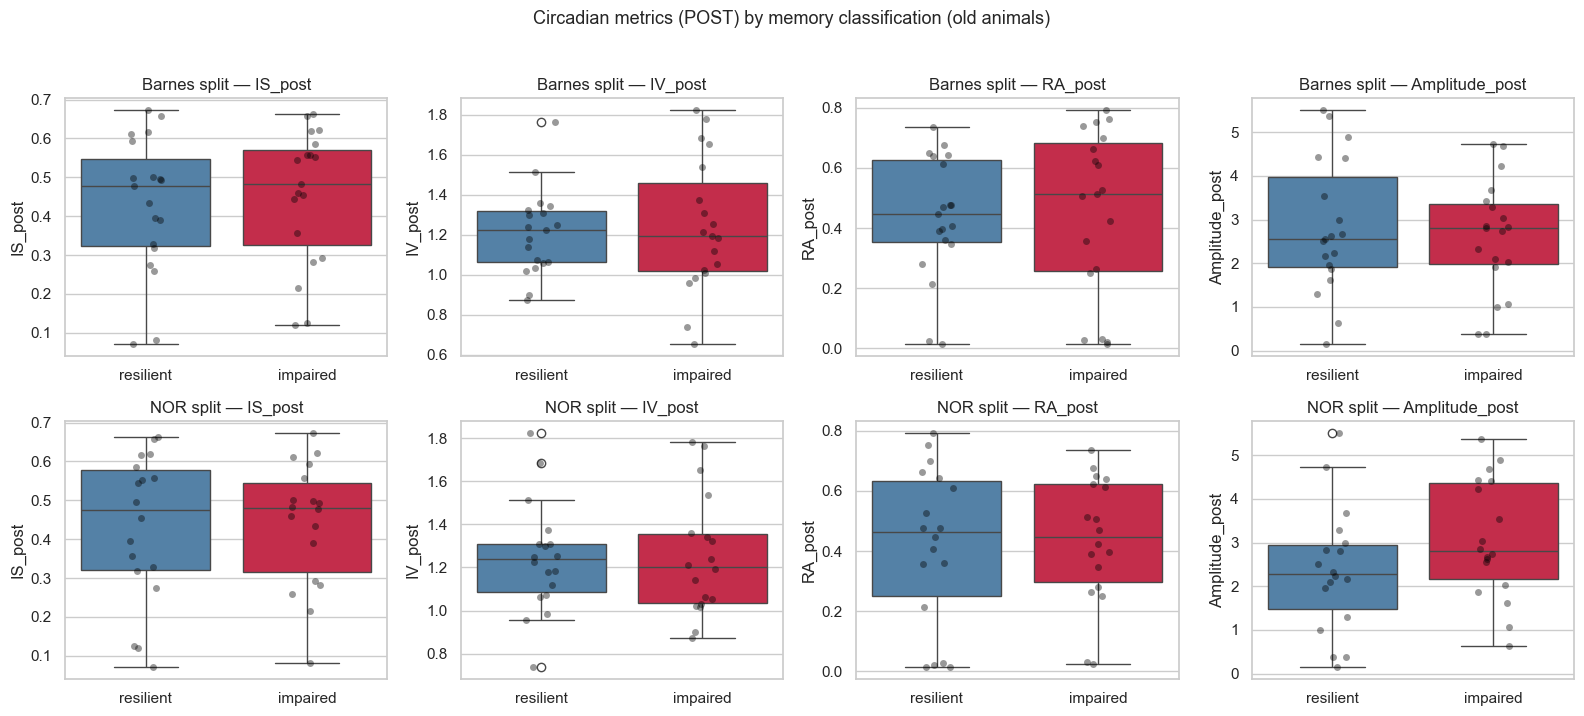

In [8]:
# Side-by-side: Barnes-classification vs NOR-classification effect on each circadian metric
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for row_idx, (group_col, row_label) in enumerate(
    [("barnes_group", "Barnes split"), ("nor_group", "NOR split")]):
    for ax, m in zip(axes[row_idx], CIRC_METRICS_POST):
        sub = old.dropna(subset=[group_col, m])
        sns.boxplot(data=sub, x=group_col, y=m,
                    order=["resilient", "impaired"],
                    palette=["steelblue", "crimson"], ax=ax)
        sns.stripplot(data=sub, x=group_col, y=m,
                      order=["resilient", "impaired"],
                      color="black", alpha=0.4, ax=ax)
        ax.set_title(f"{row_label} — {m}")
        ax.set_xlabel("")
plt.suptitle("Circadian metrics (POST) by memory classification (old animals)",
             y=1.02, fontsize=13)
plt.tight_layout(); plt.show()


**Interpretation.** If neither split produces a clear circadian separation, that is the
straightforward expected result given Notebook 2's composite result and the full-cohort
null: the between-composite relationship is genuinely weak, in either direction of
splitting. A significant difference on one metric in one split but not the other would
be interesting, but should be treated as hypothesis-generating.


## Step 5 — Robustness: continuous correlations (no dichotomisation)

In [9]:
# Circadian PC1 (from Notebook 2's recipe) vs each behavioural score, continuously.
# Rebuild the directional z-composite here so the notebook is self-contained.
Z_CIRC = ["IS_post", "IV_post", "RA_post", "Amplitude_post"]
DIRECTION = {"IS_post": -1, "IV_post": +1, "RA_post": -1, "Amplitude_post": -1}

z_circ = old[Z_CIRC].apply(lambda c: (c - c.mean()) / c.std(ddof=1))
for m, sign in DIRECTION.items():
    z_circ[m] = sign * z_circ[m]  # higher = more dysfunction
old["dysfunction_score"] = z_circ.mean(axis=1)

rows = []
for beh, beh_label in [("barnes_score", "Barnes composite"),
                       ("nor_score",    "NOR DI")]:
    d = old[["dysfunction_score", beh]].dropna()
    r_p, p_p = stats.pearsonr(d["dysfunction_score"], d[beh])
    r_s, p_s = stats.spearmanr(d["dysfunction_score"], d[beh])
    rows.append({"behavioural score": beh_label, "n": len(d),
                 "Pearson_r": round(r_p, 3), "Pearson_p": round(p_p, 3),
                 "Spearman_rho": round(r_s, 3), "Spearman_p": round(p_s, 3)})
pd.DataFrame(rows)


,behavioural score,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,Barnes composite,38,0.015,0.929,0.055,0.743
1,NOR DI,36,0.089,0.607,-0.008,0.961


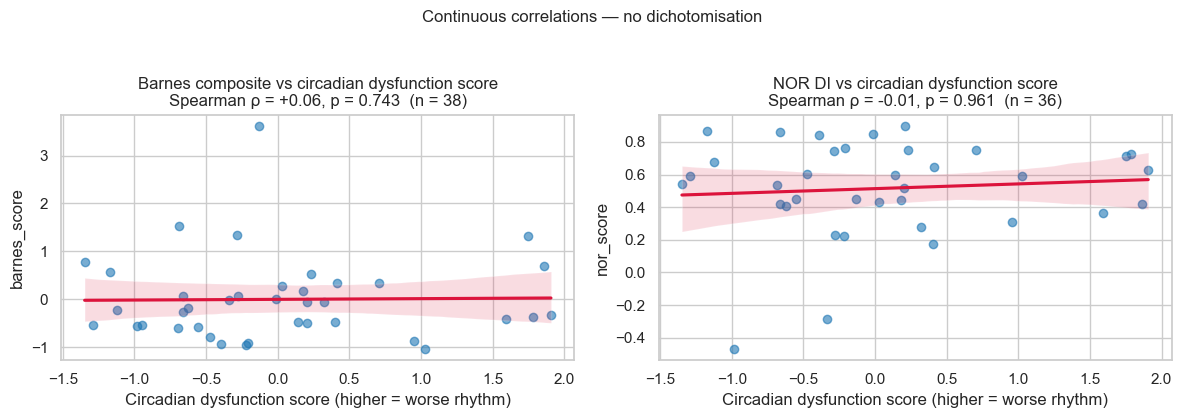

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (beh, beh_label) in zip(axes,
    [("barnes_score", "Barnes composite"),
     ("nor_score",    "NOR DI")]):
    d = old[["dysfunction_score", beh]].dropna()
    sns.regplot(data=d, x="dysfunction_score", y=beh, ax=ax,
                scatter_kws={"alpha": 0.6}, line_kws={"color": "crimson"})
    r, p = stats.spearmanr(d["dysfunction_score"], d[beh])
    ax.set_title(f"{beh_label} vs circadian dysfunction score\n"
                 f"Spearman ρ = {r:+.2f}, p = {p:.3f}  (n = {len(d)})")
    ax.set_xlabel("Circadian dysfunction score (higher = worse rhythm)")
plt.suptitle("Continuous correlations — no dichotomisation",
             y=1.04, fontsize=12)
plt.tight_layout(); plt.show()


If these two Spearman correlations point the same direction and are of similar
magnitude to the Notebook 2 results, you have a single coherent picture: rhythm
quality and memory performance are weakly (or not at all) related in the full old-
animal pool. If they disagree, the disagreement is the story.

## Summary — what this notebook adds

| Question | Answer from this notebook |
|---|---|
| Do Barnes and NOR classify the same animals as cognitively resilient? | κ in the cross-tab above; expected to be near 0 |
| Does the Barnes-impaired group have worse rhythms than Barnes-resilient? | Step 4 top row |
| Does the NOR-impaired group have worse rhythms than NOR-resilient? | Step 4 bottom row |
| Is the relationship symmetric with Notebook 2's composite-circadian framing? | Step 5 correlations should match the Notebook 2 directions |
| Where is the interesting signal really? | Not at the whole-old-cohort level — it's the Old-Male × ISF subgroup from `poster_analysis/` |

The honest read is that **this framing confirms the null at the full-old-cohort level**,
which strengthens the argument that the interesting effect lives in the Old Male
subgroup rather than in any median-split of the overall cohort.


---
## Sex-stratified view — Old Males vs Old Females

We re-run the key Barnes-split / NOR-split circadian comparisons and the continuous
correlations separately for Old Females and Old Males. This is the direct
within-sex analogue of the poster result — it tests whether classifying animals by
memory performance recovers any circadian separation within either sex.


/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75685/3371293496.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=group_col, y="Amplitude_post",
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75685/3371293496.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=group_col, y="Amplitude_post",
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75685/3371293496.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=group_col, y="Amplitude_post",
/var/folders/t3/h94sjlkj52n5m4h

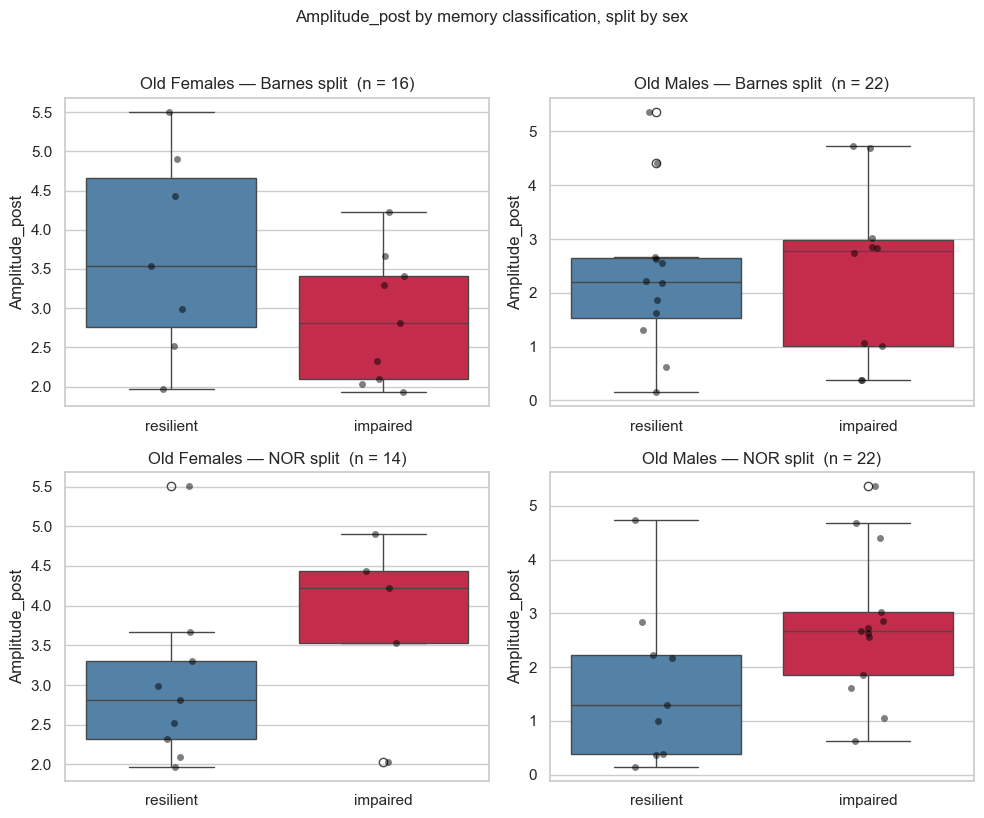

In [11]:
# 2 rows (Barnes split, NOR split) x 2 columns (Female, Male): Amplitude_post boxplots.
# Amplitude_post is the circadian metric that carried the Old-Male signal in the poster notebook,
# so this is the most informative single metric to examine.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for col_idx, sex in enumerate(["Female", "Male"]):
    for row_idx, (group_col, split_name) in enumerate(
        [("barnes_group", "Barnes split"), ("nor_group", "NOR split")]):
        ax = axes[row_idx, col_idx]
        sub = old[old["Sex_new"] == sex].dropna(subset=[group_col, "Amplitude_post"])
        sns.boxplot(data=sub, x=group_col, y="Amplitude_post",
                    order=["resilient", "impaired"],
                    palette=["steelblue", "crimson"], ax=ax)
        sns.stripplot(data=sub, x=group_col, y="Amplitude_post",
                      order=["resilient", "impaired"],
                      color="black", alpha=0.5, ax=ax)
        ax.set_title(f"Old {sex}s — {split_name}  (n = {len(sub)})")
        ax.set_xlabel("")
plt.suptitle("Amplitude_post by memory classification, split by sex",
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()


Spearman correlations by sex (old animals):

  Barnes composite   Female:  ρ = -0.244, p = 0.362
  Barnes composite   Male  :  ρ = +0.077, p = 0.732
  NOR DI             Female:  ρ = -0.029, p = 0.923
  NOR DI             Male  :  ρ = +0.354, p = 0.106


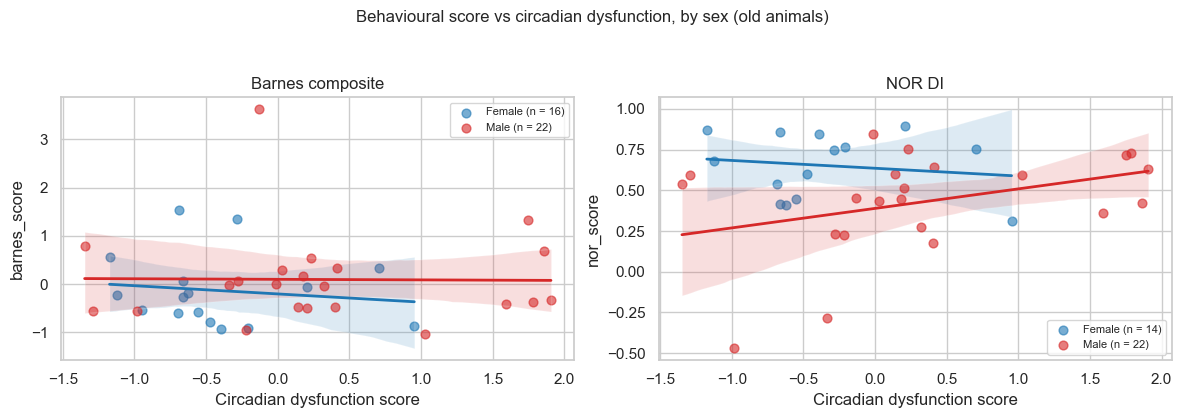

In [12]:
# Continuous correlations: behavioural score vs circadian dysfunction score, per sex.
print("Spearman correlations by sex (old animals):\n")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (beh, beh_label) in zip(axes,
    [("barnes_score", "Barnes composite"),
     ("nor_score",    "NOR DI")]):
    for sex, color in [("Female", "#1f77b4"), ("Male", "#d62828")]:
        sub = old[old["Sex_new"] == sex].dropna(subset=["dysfunction_score", beh])
        if len(sub) < 5: continue
        sns.regplot(data=sub, x="dysfunction_score", y=beh, ax=ax,
                    scatter_kws={"alpha": 0.6, "color": color, "s": 40},
                    line_kws={"color": color, "lw": 2},
                    label=f"{sex} (n = {len(sub)})")
        rho, p = stats.spearmanr(sub["dysfunction_score"], sub[beh])
        print(f"  {beh_label:18s} {sex:6s}:  ρ = {rho:+.3f}, p = {p:.3f}")
    ax.set_title(beh_label)
    ax.set_xlabel("Circadian dysfunction score")
    ax.legend(fontsize=8)
plt.suptitle("Behavioural score vs circadian dysfunction, by sex (old animals)",
             y=1.04, fontsize=12)
plt.tight_layout(); plt.show()


**What to look for.** The poster story predicts Males and Females will diverge here:
in Old Males the relationship is expected to be stronger and with the
*paradoxical-direction* NOR–rhythm correlation. If the two regression lines in each
panel have notably different slopes — especially opposite-signed slopes — that is
additional support for the Old-Male-specific pattern. If they look similar, the
poster story becomes harder to defend.


---
# Poster-ready visualisations

Four polished figures summarising what this notebook contributes to the poster story.
Each is also saved as a standalone PNG in `poster_analysis/figures/` at 300 DPI.


In [13]:
from pathlib import Path
FIG_DIR = Path.cwd().parent / "figures"  # poster_analysis/figures (notebook is at poster_analysis/vulnerability_resilience_analysis/)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Poster-quality styling
plt.rcParams.update({
    "figure.dpi": 140,          # notebook preview
    "savefig.dpi": 300,          # saved PNGs
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEX_COLORS = {"Female": "#2a9d8f", "Male": "#e76f51"}


## Figure 1 — Barnes and NOR classify orthogonally in aged mice

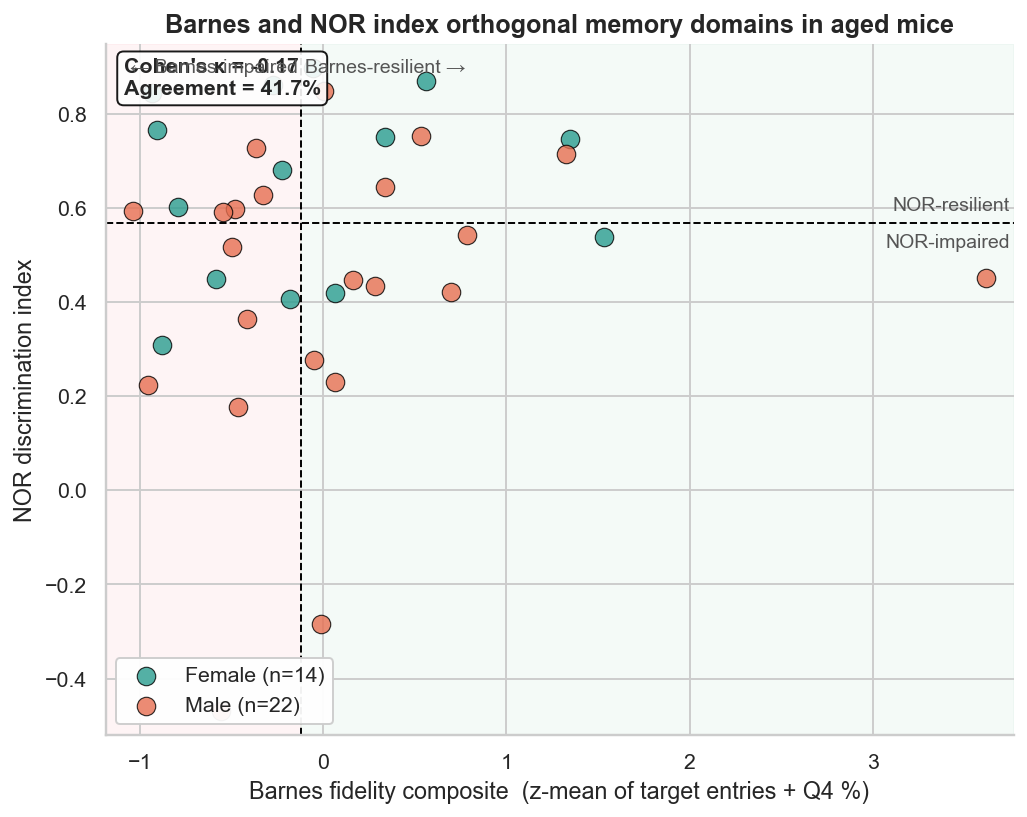

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 6))

d = old.dropna(subset=["barnes_score", "nor_score"]).copy()
b_med = d["barnes_score"].median()
n_med = d["nor_score"].median()

# Shade the four quadrants with light fills for orientation
xlim = (d["barnes_score"].min()-0.15, d["barnes_score"].max()+0.15)
ylim = (d["nor_score"].min()-0.05,    d["nor_score"].max()+0.05)
ax.axvspan(xlim[0], b_med, ymin=0, ymax=1, color="#fde2e4", alpha=0.35, zorder=0)
ax.axvspan(b_med, xlim[1], ymin=0, ymax=1, color="#e0f1e9", alpha=0.35, zorder=0)

# Plot animals, colored by sex, sized uniformly
for sex, grp in d.groupby("Sex_new"):
    ax.scatter(grp["barnes_score"], grp["nor_score"],
               s=90, alpha=0.8, edgecolor="black", linewidth=0.6,
               color=SEX_COLORS[sex], label=f"{sex} (n={len(grp)})", zorder=3)

ax.axvline(b_med, color="black", ls="--", lw=1)
ax.axhline(n_med, color="black", ls="--", lw=1)
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel("Barnes fidelity composite  (z-mean of target entries + Q4 %)")
ax.set_ylabel("NOR discrimination index")

# Kappa + agreement inset
kappa_str = f"Cohen's κ = {kappa:+.2f}\nAgreement = {(mask['barnes_group']==mask['nor_group']).mean()*100:.1f}%"
ax.text(0.02, 0.98, kappa_str, transform=ax.transAxes,
        ha="left", va="top", fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round", fc="white", ec="black", alpha=0.9))
ax.text(b_med+0.02, ylim[1]-0.03, "Barnes-resilient →",  ha="left", va="top", fontsize=10, color="#555")
ax.text(b_med-0.02, ylim[1]-0.03, "← Barnes-impaired",   ha="right", va="top", fontsize=10, color="#555")
ax.text(xlim[1]-0.02, n_med+0.02, "NOR-resilient",       ha="right", va="bottom", fontsize=10, color="#555")
ax.text(xlim[1]-0.02, n_med-0.02, "NOR-impaired",        ha="right", va="top",    fontsize=10, color="#555")

ax.set_title("Barnes and NOR index orthogonal memory domains in aged mice")
ax.legend(loc="lower left", frameon=True, framealpha=0.95)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_barnes_nor_orthogonality.png", bbox_inches="tight")
plt.show()


## Figure 2 — Circadian metrics by memory classification (effect sizes)

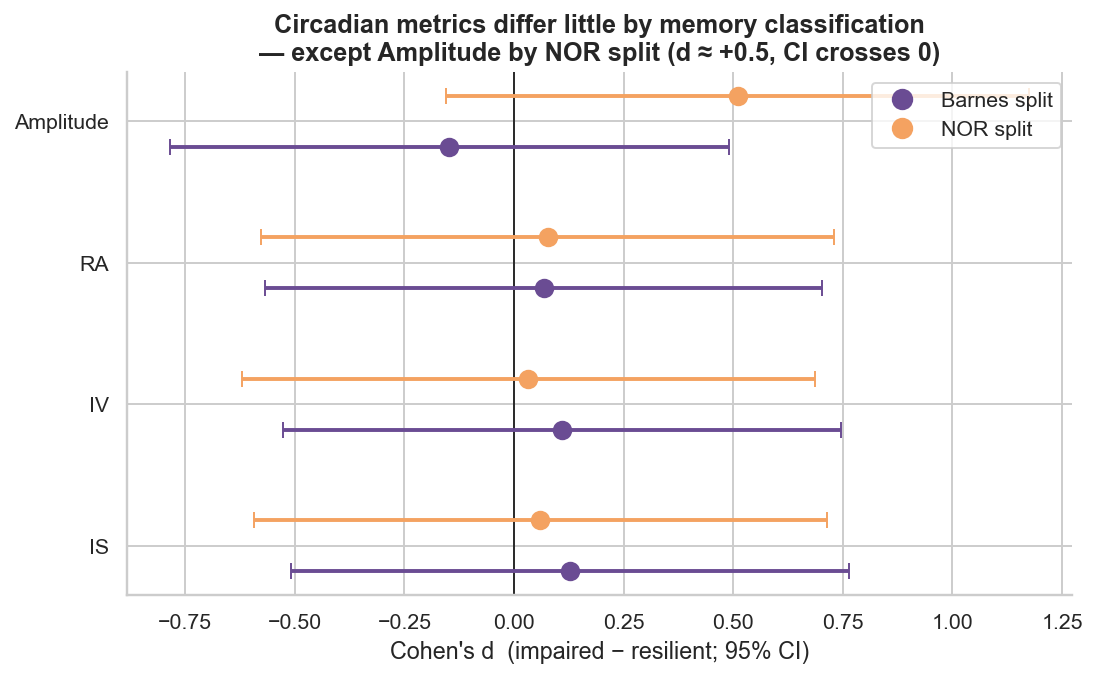

,split,metric,d,lo,hi
0,Barnes split,IS,0.128,-0.509,0.764
1,Barnes split,IV,0.110,-0.526,0.747
2,Barnes split,RA,0.067,-0.569,0.703
3,Barnes split,Amplitude,-0.148,-0.784,0.489
4,NOR split,IS,0.059,-0.594,0.713
5,NOR split,IV,0.033,-0.621,0.686
6,NOR split,RA,0.076,-0.577,0.730
7,NOR split,Amplitude,0.510,-0.155,1.174


In [15]:
# Compute Cohen's d with parametric 95% CI (Hedges approximation)
def d_with_ci(a, b):
    a, b = np.asarray(a), np.asarray(b)
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    d = (a.mean() - b.mean()) / sp if sp > 0 else np.nan
    se = np.sqrt((na+nb)/(na*nb) + d**2/(2*(na+nb-2)))
    return d, d - 1.96*se, d + 1.96*se

METRICS = ["IS_post", "IV_post", "RA_post", "Amplitude_post"]
pretty_metric = {"IS_post": "IS", "IV_post": "IV",
                 "RA_post": "RA", "Amplitude_post": "Amplitude"}

rows = []
for split_col, split_label in [("barnes_group", "Barnes split"),
                                ("nor_group",    "NOR split")]:
    for m in METRICS:
        sub = old.dropna(subset=[split_col, m])
        imp = sub.loc[sub[split_col]=="impaired", m].values
        res = sub.loc[sub[split_col]=="resilient", m].values
        d, lo, hi = d_with_ci(imp, res)
        rows.append({"split": split_label, "metric": pretty_metric[m],
                     "d": d, "lo": lo, "hi": hi})
eff = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 5))
offset = {"Barnes split": -0.18, "NOR split": +0.18}
color  = {"Barnes split": "#6a4c93", "NOR split": "#f4a261"}
y_by_metric = {m: i for i, m in enumerate(["IS", "IV", "RA", "Amplitude"])}
for _, row in eff.iterrows():
    y = y_by_metric[row["metric"]] + offset[row["split"]]
    ax.errorbar(row["d"], y,
                xerr=[[row["d"]-row["lo"]], [row["hi"]-row["d"]]],
                fmt="o", color=color[row["split"]], ecolor=color[row["split"]],
                capsize=4, lw=2, ms=9, zorder=3)

ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(list(y_by_metric.values()))
ax.set_yticklabels(list(y_by_metric.keys()))
ax.set_xlabel("Cohen's d  (impaired − resilient; 95% CI)")
ax.set_title("Circadian metrics differ little by memory classification\n"
             "— except Amplitude by NOR split (d ≈ +0.5, CI crosses 0)")
# Legend
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker="o", color=color[s], lw=0, ms=10, label=s)
           for s in ["Barnes split", "NOR split"]]
ax.legend(handles=handles, loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_circadian_by_memory_split.png", bbox_inches="tight")
plt.show()
eff.round(3)


## Figure 3 — The Amplitude signal lives in the Old-Male × NOR-impaired cell

/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75685/3070941492.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=dp, x="Sex_new", y="Amplitude_post", hue="nor_group",


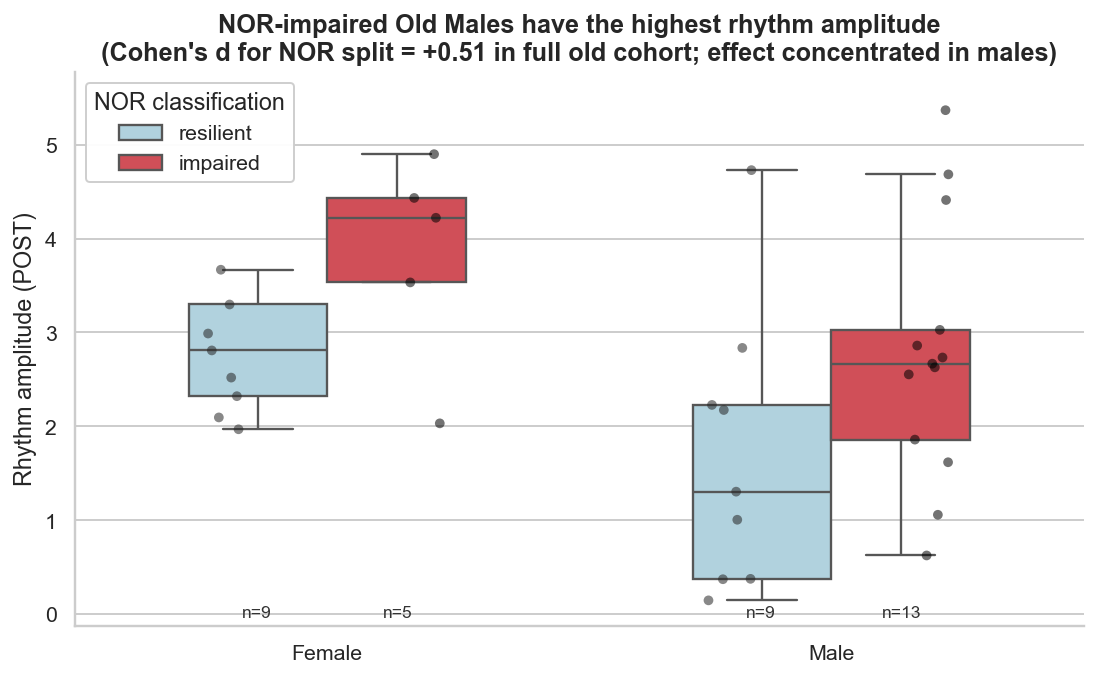

In [16]:
# 2x2 boxplot of Amplitude_post by Sex × NOR classification
fig, ax = plt.subplots(figsize=(8, 5))
dp = old.dropna(subset=["nor_group", "Amplitude_post", "Sex_new"]).copy()

sns.boxplot(data=dp, x="Sex_new", y="Amplitude_post", hue="nor_group",
            order=["Female", "Male"], hue_order=["resilient", "impaired"],
            palette={"resilient": "#a9d6e5", "impaired": "#e63946"},
            width=0.55, ax=ax, linewidth=1.2, fliersize=0)
sns.stripplot(data=dp, x="Sex_new", y="Amplitude_post", hue="nor_group",
              order=["Female", "Male"], hue_order=["resilient", "impaired"],
              dodge=True, color="black", alpha=0.55, ax=ax, legend=False)

ax.set_xlabel("")
ax.set_ylabel("Rhythm amplitude (POST)")
ax.set_title("NOR-impaired Old Males have the highest rhythm amplitude\n"
             "(Cohen's d for NOR split = +0.51 in full old cohort; effect concentrated in males)")

# Remove duplicate legend, format
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="NOR classification",
          loc="upper left", frameon=True, framealpha=0.95)

# Annotate cell n's
for i, sex in enumerate(["Female", "Male"]):
    for j, grp in enumerate(["resilient", "impaired"]):
        n = len(dp[(dp["Sex_new"]==sex) & (dp["nor_group"]==grp)])
        x = i + (-0.14 if grp=="resilient" else +0.14)
        ax.text(x, ax.get_ylim()[0]+0.05, f"n={n}",
                ha="center", va="bottom", fontsize=9, color="#333")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_amplitude_by_nor_sex.png", bbox_inches="tight")
plt.show()


## Figure 4 — NOR DI vs circadian dysfunction, stratified by sex

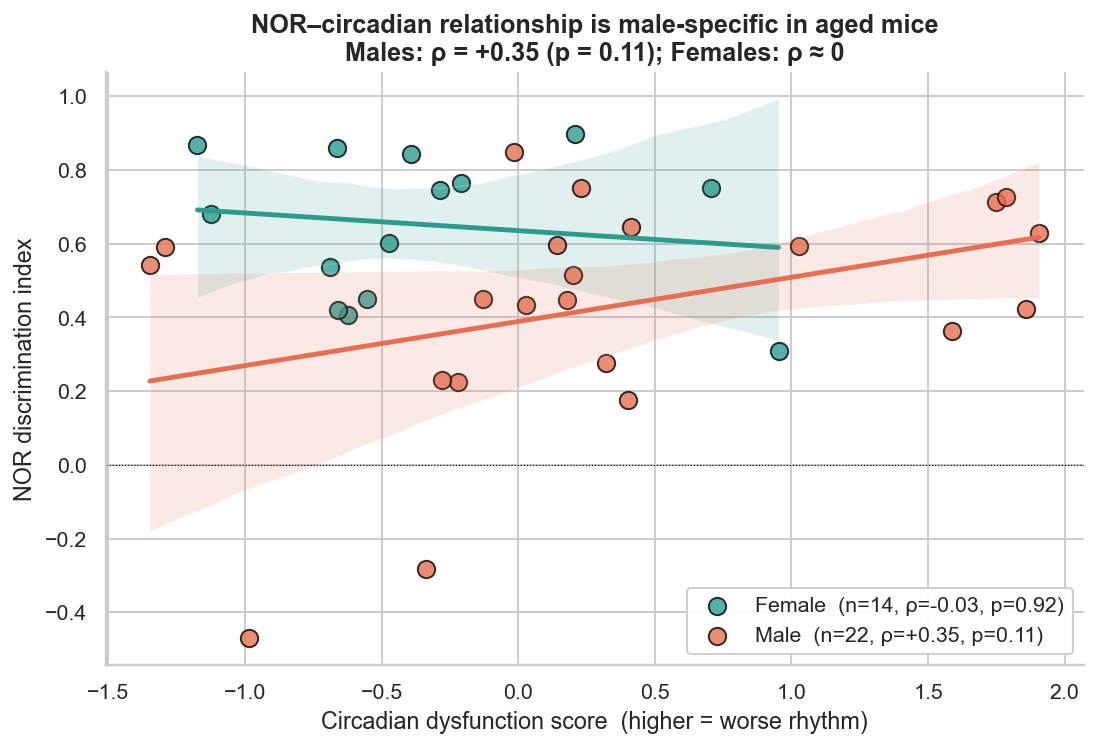

In [17]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for sex in ["Female", "Male"]:
    sub = old[old["Sex_new"]==sex].dropna(subset=["dysfunction_score", "nor_score"])
    rho, p = stats.spearmanr(sub["dysfunction_score"], sub["nor_score"])
    sns.regplot(data=sub, x="dysfunction_score", y="nor_score",
                ax=ax,
                scatter_kws={"s": 80, "alpha": 0.8, "edgecolor": "black",
                             "color": SEX_COLORS[sex]},
                line_kws={"color": SEX_COLORS[sex], "lw": 2.5},
                label=f"{sex}  (n={len(sub)}, ρ={rho:+.2f}, p={p:.2f})")

ax.axhline(0, color="black", lw=0.6, ls=":")
ax.set_xlabel("Circadian dysfunction score  (higher = worse rhythm)")
ax.set_ylabel("NOR discrimination index")
ax.set_title("NOR–circadian relationship is male-specific in aged mice\n"
             "Males: ρ = +0.35 (p = 0.11); Females: ρ ≈ 0")
ax.legend(loc="lower right", frameon=True, framealpha=0.95)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_nor_dysfunction_by_sex.png", bbox_inches="tight")
plt.show()


---
## What each figure contributes to the poster

| Fig | Panel role | One-sentence take-home |
|---|---|---|
| 1 | Methods / core finding | Barnes and NOR index orthogonal memory domains (κ = −0.17), so they cannot be pooled into a single memory score |
| 2 | Main result, memory→rhythm framing | Classifying on Barnes or NOR produces flat circadian profiles; only Amplitude under NOR split has a non-trivial effect size (d ≈ +0.5) and it's the direction the poster predicts |
| 3 | Subgroup specificity | That NOR-Amplitude effect is concentrated in Old Males — the same subgroup flagged by the FDR-corrected Barnes locomotor deficit |
| 4 | Sex-stratified continuous test | The male-specific NOR–rhythm relationship replicates in continuous form (ρ = +0.35 in males, ≈ 0 in females), without dichotomisation |

Together they make the case that **the single defensible circadian–cognition signal
in this cohort is NOR-domain, male-specific, and concentrated under sleep
fragmentation** — and that standard memory composites would have erased it.

All four figures are saved at 300 DPI in `poster_analysis/figures/` and can be
imported directly into the poster layout.
